In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle 
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

## Funciones

In [173]:
def aplicar_transformaciones(df, stats=None, es_train=True):
    df = df.copy()

    pay_cols = [f'PAY_{i}' for i in range(2,7)]        # PAY_2 a PAY_6, sin PAY_0 ni PAY_00
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(2,7)] # PAY_AMT2 a PAY_AMT6 (sin PAY_AMT1)
    bill_amt_cols = [f'BILL_AMT{i}' for i in range(1,7)]

    # Variables directas (sin usar PAY_AMT1)
    df['Ratio_Debt'] = df[bill_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Max_Estatus_Pay'] = df[pay_cols].max(axis=1)
    df['Promedio_Estatus_Pay'] = df[pay_cols].mean(axis=1)
    df['Ratio_Payment'] = df[pay_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Count_Pay_Retrasados'] = (df[pay_cols] > 0).sum(axis=1)
    df['Count_Pay_A_Tiempo'] = (df[pay_cols] == -1).sum(axis=1)
    df['Total_Pay'] = df[pay_amt_cols].sum(axis=1)
    df['Total_Bill'] = df[bill_amt_cols].sum(axis=1)
    df['Pay/Bill'] = np.where(df['Total_Bill'] == 0, 0, df['Total_Pay'] / df['Total_Bill'])
    df['Pay_tendencia'] = df['PAY_AMT2'] - df['PAY_AMT6']
    df['Bill_tendencia'] = df['BILL_AMT2'] - df['BILL_AMT6']
    df['Diff_Bill_Pay'] = df['Total_Bill'] - df['Total_Pay']
    df['Diff_Bill_Pay_Tendencia'] = (df['BILL_AMT2'] - df['PAY_AMT2']) - (df['BILL_AMT6'] - df['PAY_AMT6'])

    df['Meses_Pago_Completo'] = sum([
        (df[f'PAY_AMT{i}'] >= df[f'BILL_AMT{i}']).astype(int)
        for i in range(2, 7)
    ])

    df['Meses_Deuda'] = sum([
        (df[f'PAY_AMT{i}'] <= df[f'BILL_AMT{i}']).astype(int)
        for i in range(2, 7)
    ])

    # Inicializar stats si es None
    if stats is None:
        stats = {}

    # Estadísticas y bins calculados solo en train
    if es_train:
        stats['pay_std'] = df[pay_amt_cols].std(axis=1).mean()
        stats['pay_mean'] = df[pay_amt_cols].mean(axis=1).mean()
        stats['bill_mean'] = df[bill_amt_cols].mean(axis=1).mean()

        # Calcular bins para AGE con qcut y guardar en stats
        _, bins_age = pd.qcut(df['AGE'], q=4, retbins=True, duplicates='drop')
        stats['age_bins'] = bins_age
        stats['age_labels'] = ['Joven', 'Adulto joven', 'Adulto', 'Mayor']
    else:
        # Verificar que stats esté completo para validación/test
        for key in ['pay_std', 'pay_mean', 'bill_mean', 'age_bins', 'age_labels']:
            if key not in stats:
                raise ValueError(f"La estadística '{key}' debe ser proporcionada en 'stats' cuando es_train=False.")

    # Aplicar Age_Quartile con bins guardados en stats
    df['Age_Quartile'] = pd.cut(df['AGE'], bins=stats['age_bins'], labels=stats['age_labels'], include_lowest=True, right=True).astype(str)
    df['Age_Quartile'] = df['Age_Quartile'].fillna('Desconocido')

    # Transformaciones con stats para imputación
    df['Pago_desviacion'] = df[pay_amt_cols].std(axis=1).fillna(stats['pay_std'])
    df['Pay_amount_mean'] = df[pay_amt_cols].mean(axis=1).fillna(stats['pay_mean'])
    df['Bill_amount_mean'] = df[bill_amt_cols].mean(axis=1).fillna(stats['bill_mean'])

    df['Pay_tendencia_Amplia'] = df[pay_amt_cols[:3]].mean(axis=1) - df[pay_amt_cols[3:]].mean(axis=1)
    df['Bill_tendencia_Amplia'] = df[bill_amt_cols[:3]].mean(axis=1) - df[bill_amt_cols[3:]].mean(axis=1)

    df['Diff_Bill_Pay_Tendencia_Amplia'] = (
        df[bill_amt_cols[:3]].mean(axis=1) - df[pay_amt_cols[:3]].mean(axis=1) -
        (df[bill_amt_cols[3:]].mean(axis=1) - df[pay_amt_cols[3:]].mean(axis=1))
    )

    # Tendencias ponderadas
    pesos = [1, 0.75, 0.6, 0.45, 0.3, 0.15]
    df['Pay_tendencia_ponderada'] = sum([
        df[f'PAY_AMT{i}'] * peso for i, peso in zip(range(2, 7), pesos[1:])
    ])
    df['Bill_tendencia_ponderada'] = sum([
        df[f'BILL_AMT{i}'] * peso for i, peso in zip(range(1, 7), pesos)
    ])

    return (df, stats) if es_train else df


## Analisis de Datos

### Lectura de Datos

In [174]:
seed = 666
np.random.seed(seed)

In [175]:
df = pd.read_csv('datos/train_PAY_AMT1.csv', sep = '|' )

In [176]:
pd.set_option('display.max_columns',None)
df

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20558,80000.0,2,3,2,28,0,0,0,0,0,77450.0,78100.0,76204.0,66876.0,66182.0,67199.0,3500.0,2600.0,2400.0,2500.0,2700.0,2300.0
1,5767,280000.0,2,2,1,37,0,0,0,0,0,29078.0,30144.0,32629.0,35126.0,35759.0,42317.0,1515.0,3000.0,3000.0,1292.0,7147.0,1415.0
2,664,140000.0,2,3,2,59,2,0,0,0,0,63654.0,62042.0,63445.0,63729.0,63751.0,65421.0,0.0,3000.0,2000.0,2000.0,2000.0,3000.0
3,17845,160000.0,1,2,1,52,-1,2,-1,2,-1,390.0,780.0,390.0,1080.0,540.0,390.0,780.0,0.0,1080.0,0.0,390.0,390.0
4,7324,90000.0,2,2,2,23,0,0,0,0,0,13107.0,13740.0,14770.0,13306.0,10465.0,9704.0,1251.0,1281.0,1173.0,500.0,1000.0,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,13139,80000.0,1,3,1,49,0,0,0,-2,-2,77985.0,80886.0,82150.0,0.0,0.0,0.0,4200.0,3800.0,0.0,0.0,0.0,0.0
5621,22206,80000.0,1,3,1,42,-2,-2,-2,-2,-2,-1590.0,-6256.0,-10922.0,-15588.0,-20254.0,-24920.0,4666.0,4666.0,4666.0,4666.0,266.0,0.0
5622,19489,340000.0,2,2,1,36,0,0,0,0,0,3058.0,4087.0,5129.0,3142.0,3210.0,4153.0,1087.0,1129.0,1052.0,120.0,1000.0,1000.0
5623,27693,20000.0,2,2,1,43,0,0,0,0,0,6459.0,7470.0,8492.0,9547.0,20766.0,12197.0,1123.0,1145.0,1200.0,2000.0,3000.0,1000.0


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5625 entries, 0 to 5624
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CUSTOMER_ID  5625 non-null   int64  
 1   LIMIT_BAL    5625 non-null   float64
 2   SEX          5625 non-null   int64  
 3   EDUCATION    5625 non-null   int64  
 4   MARRIAGE     5625 non-null   int64  
 5   AGE          5625 non-null   int64  
 6   PAY_2        5625 non-null   int64  
 7   PAY_3        5625 non-null   int64  
 8   PAY_4        5625 non-null   int64  
 9   PAY_5        5625 non-null   int64  
 10  PAY_6        5625 non-null   int64  
 11  BILL_AMT1    5625 non-null   float64
 12  BILL_AMT2    5625 non-null   float64
 13  BILL_AMT3    5625 non-null   float64
 14  BILL_AMT4    5625 non-null   float64
 15  BILL_AMT5    5625 non-null   float64
 16  BILL_AMT6    5625 non-null   float64
 17  PAY_AMT1     5625 non-null   float64
 18  PAY_AMT2     5625 non-null   float64
 19  PAY_AM

In [178]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000
mean,14881.272000,170283.733333,1.609244,1.858844,1.547022,35.480178,-0.150222,-0.184889,-0.240000,-0.279822,-0.304178,51475.919111,49794.312711,47538.054756,43886.864533,40847.769778,39533.191467,6050.843378,5438.163022,5189.431644,4839.233956,4776.414222,5069.621689
std,8655.054802,131513.486564,0.487963,0.788872,0.523252,9.204122,1.195956,1.194740,1.147234,1.099395,1.120461,72596.576983,70303.014428,68324.469908,64145.186775,60618.464156,59577.948403,18509.895896,14978.604883,16795.769086,15367.922842,14710.034313,16633.591621
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-33350.000000,-15641.000000,-15588.000000,-81334.000000,-51443.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,267.720000,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-56.080000,-197.360000,-203.040000,-191.280000,-200.000000,-200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5%,1414.200000,20000.000000,1.000000,1.000000,1.000000,23.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7358.000000,60000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3724.000000,3077.000000,2786.000000,2126.000000,1639.000000,1346.000000,1000.000000,832.000000,396.000000,311.000000,300.000000,189.000000
50%,14903.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22957.000000,21705.000000,20424.000000,19212.000000,18187.000000,17328.000000,2200.000000,2065.000000,1862.000000,1500.000000,1604.000000,1500.000000
75%,22352.000000,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68168.000000,65785.000000,60992.000000,55957.000000,52471.000000,50524.000000,5096.000000,5000.000000,4773.000000,4000.000000,4300.000000,4000.000000
95%,28393.000000,440000.000000,2.000000,3.000000,2.000000,53.000000,2.000000,2.000000,2.000000,2.000000,2.000000,203751.400000,196812.200000,190039.400000,178143.200000,167937.000000,165179.400000,19288.200000,19024.000000,17642.400000,16038.800000,15017.000000,16897.200000


In [179]:
df.isnull().sum()

CUSTOMER_ID    0
LIMIT_BAL      0
SEX            0
EDUCATION      0
MARRIAGE       0
AGE            0
PAY_2          0
PAY_3          0
PAY_4          0
PAY_5          0
PAY_6          0
BILL_AMT1      0
BILL_AMT2      0
BILL_AMT3      0
BILL_AMT4      0
BILL_AMT5      0
BILL_AMT6      0
PAY_AMT1       0
PAY_AMT2       0
PAY_AMT3       0
PAY_AMT4       0
PAY_AMT5       0
PAY_AMT6       0
dtype: int64

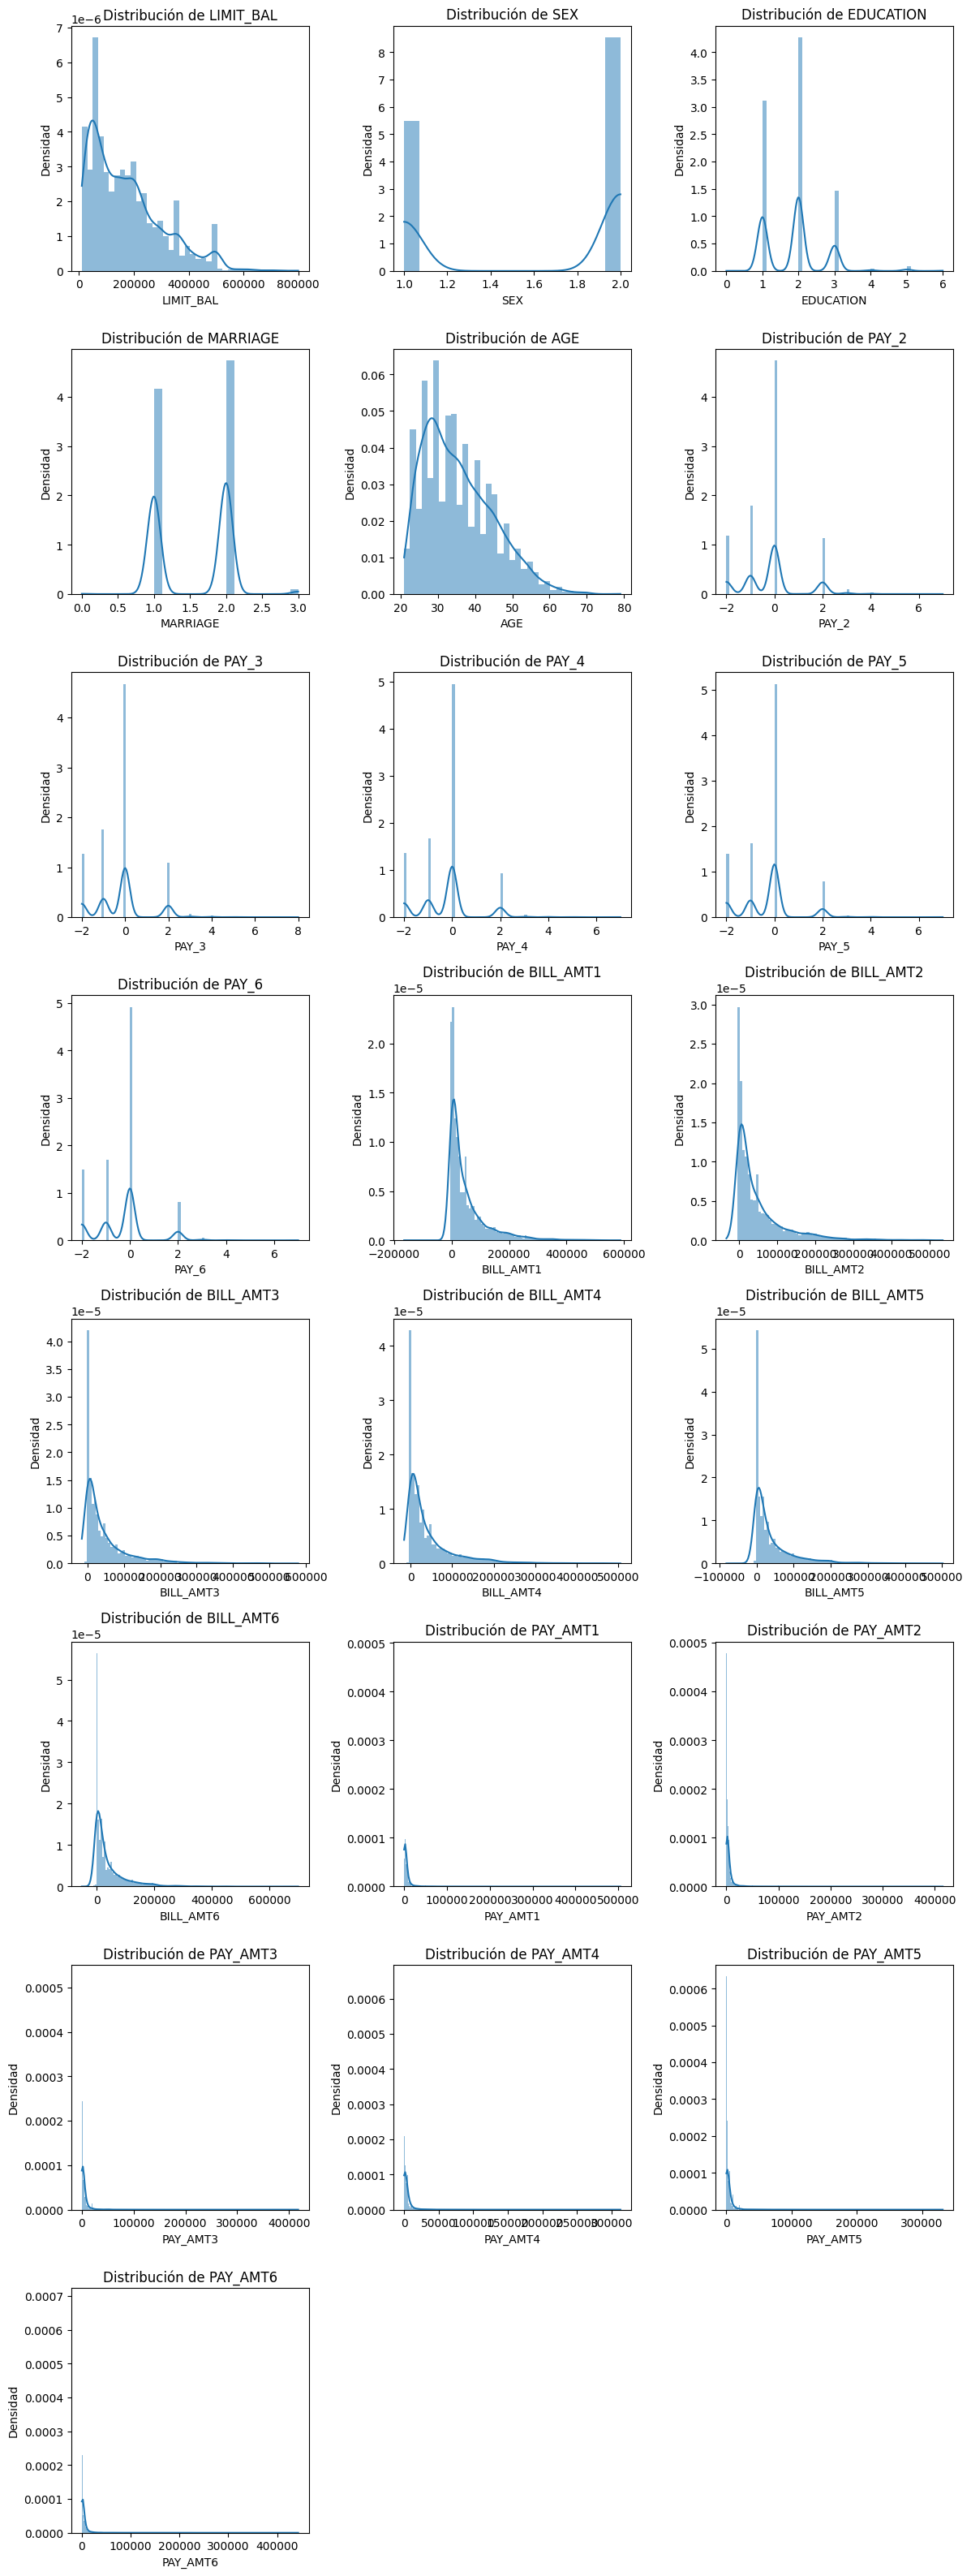

In [180]:
aux = df.drop(columns = 'CUSTOMER_ID')
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

## Ingenieria de variables

In [181]:
X_train, X_test , y_train, y_test = train_test_split(df.drop(columns=['CUSTOMER_ID','PAY_AMT1']), 
                                                     df['PAY_AMT1'], train_size=0.7, random_state=seed)

In [182]:
df = X_train.copy()

In [183]:
df, stats = aplicar_transformaciones(df, stats=None,es_train=True)

In [184]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
1779,110000.0,2,2,1,33,2,0,0,0,0,7801.0,5289.0,9893.0,9986.0,9981.0,11714.0,5000.0,500.0,400.0,2000.0,0.0,0.496945,2,0.4,0.071818,1,0,7900.0,54664.0,0.144519,5000.0,-6425.0,46764.0,-11425.0,0,5,Adulto joven,2057.182539,1580.0,9110.666667,966.666667,-2899.333333,-3866.000000,4830.00,26948.65
1070,60000.0,1,2,1,48,0,0,0,0,-1,60924.0,60089.0,59828.0,58217.0,18527.0,40334.0,2800.0,2000.0,1110.0,40621.0,1800.0,4.965317,0,-0.2,0.805517,0,1,48331.0,297919.0,0.162229,1000.0,19755.0,249588.0,18755.0,1,4,Mayor,17314.738150,9666.2,49653.166667,-19240.500000,21254.333333,40494.833333,16255.80,179693.40
3385,200000.0,1,2,2,30,-1,-1,-1,-1,-1,15140.0,18028.0,16456.0,15370.0,14966.0,16230.0,16474.0,15392.0,14972.0,16240.0,14960.0,0.480950,-1,-1.0,0.390190,0,5,78038.0,96190.0,0.811290,1514.0,1798.0,18152.0,284.0,1,4,Adulto joven,710.710067,15607.6,16031.666667,12.666667,1019.333333,1006.666667,35444.10,52375.40
2705,120000.0,2,1,1,51,0,0,0,0,0,117287.0,120290.0,116082.0,118405.0,99081.0,106300.0,6000.0,6000.0,4000.0,9000.0,0.0,5.645375,0,0.0,0.208333,0,0,25000.0,677445.0,0.036903,6000.0,13990.0,652445.0,7990.0,0,5,Mayor,3316.624790,5000.0,112907.500000,833.333333,9957.666667,9124.333333,12600.00,376105.25
4025,210000.0,2,1,1,40,0,0,0,0,0,206803.0,207471.0,152365.0,146625.0,146163.0,146180.0,5400.0,6000.0,6000.0,6000.0,10000.0,4.788605,0,0.0,0.159048,0,0,33400.0,1005607.0,0.033214,-4600.0,61291.0,972207.0,65891.0,0,5,Adulto,1874.033084,6680.0,167601.166667,-2200.000000,42557.000000,44757.000000,13650.00,585582.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,20000.0,2,3,2,52,0,0,0,0,2,18603.0,15208.0,16153.0,18175.0,19876.0,19419.0,1500.0,2300.0,2000.0,0.0,1000.0,5.371700,2,0.4,0.340000,1,0,6800.0,107434.0,0.063295,500.0,-4211.0,100634.0,-4711.0,0,5,Mayor,907.193474,1360.0,17905.666667,1433.333333,-2502.000000,-3935.333333,3555.00,56755.20
70,20000.0,1,1,2,26,2,0,0,0,0,15397.0,10403.0,7207.0,7351.0,7512.0,8380.0,1500.0,264.0,280.0,1000.0,813.0,2.812500,2,0.4,0.192850,1,0,3857.0,56250.0,0.068569,687.0,2023.0,52393.0,1336.0,0,5,Joven,520.522622,771.4,9375.000000,-225.166667,3254.666667,3479.833333,1831.35,34342.00
2878,260000.0,2,2,1,53,2,2,2,2,2,118107.0,121763.0,133107.0,133107.0,148107.0,148107.0,15000.0,0.0,15000.0,0.0,15000.0,3.085762,2,2.0,0.173077,5,0,45000.0,802298.0,0.056089,0.0,-26344.0,757298.0,-26344.0,0,5,Mayor,8215.838363,9000.0,133716.333333,2500.000000,-18781.333333,-21281.333333,20250.00,415839.75
1950,140000.0,2,2,2,26,2,2,2,2,2,118425.0,120970.0,123141.0,124622.0,125865.0,128479.0,5600.0,5000.0,4800.0,4800.0,4700.0,5.296443,2,2.0,0.177857,5,0,24900.0,741502.0,0.033580,900.0,-7509.0,716602.0,-8409.0,0,5,Joven,363.318042,4980.0,123583.666667,383.333333,-5476.666667,-5860.000000,11505.00,396148.35


In [185]:
X_test = aplicar_transformaciones(X_test, stats=stats, es_train=False)

In [186]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
3782,100000.0,2,1,2,34,0,0,0,0,2,66193.0,63155.0,50385.0,31371.0,54713.0,28347.0,5010.0,10005.0,30326.0,0.0,20000.0,2.941640,2,0.4,0.653410,1,0,65341.0,294164.0,0.222124,-14990.0,34808.0,228823.0,49798.0,0,5,Adulto joven,12155.010745,13068.2,49027.333333,5113.666667,21767.333333,16653.666667,26407.20,178573.15
4889,50000.0,2,3,1,48,-1,-1,-1,-1,-1,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,0.0,0.046800,-1,-1.0,0.031200,0,5,1560.0,2340.0,0.666667,390.0,0.0,780.0,-390.0,4,5,Mayor,174.413302,312.0,390.000000,195.000000,0.000000,-195.000000,819.00,1267.50
1302,50000.0,1,3,2,49,0,0,0,0,0,48245.0,27656.0,23168.0,20245.0,20251.0,19970.0,21578.0,1310.0,706.0,806.0,656.0,3.190700,0,0.0,0.501120,0,0,25056.0,159535.0,0.157056,20922.0,7686.0,134479.0,-13236.0,0,5,Mayor,9264.771514,5011.2,26589.166667,7133.666667,12867.666667,5734.000000,17627.40,101068.85
313,100000.0,2,1,1,30,-1,-1,-1,-2,-1,0.0,851.0,1585.0,-1.0,-1.0,2994.0,1589.0,0.0,0.0,2995.0,0.0,0.054280,-1,-1.2,0.045840,0,4,4584.0,5428.0,0.844510,1589.0,-2143.0,844.0,-3732.0,3,2,Adulto joven,1350.216168,916.8,904.666667,-967.833333,-185.333333,782.500000,2090.25,2037.60
5138,90000.0,2,2,2,23,3,3,2,2,2,82623.0,86621.0,84369.0,82117.0,84395.0,85739.0,0.0,0.0,3600.0,2900.0,3500.0,5.620711,3,2.4,0.111111,5,0,10000.0,505864.0,0.019768,-3500.0,882.0,495864.0,4382.0,0,5,Joven,1845.264209,2000.0,84310.666667,-2000.000000,454.000000,2454.000000,3015.00,273342.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,180000.0,1,2,2,26,0,0,0,0,0,93169.0,58983.0,60506.0,58458.0,60770.0,61628.0,4000.0,4000.0,4000.0,4000.0,4000.0,2.186189,0,0.0,0.111111,0,0,20000.0,393514.0,0.050824,0.0,-2645.0,373514.0,-2645.0,0,5,Joven,0.000000,4000.0,65585.666667,0.000000,10600.666667,10600.666667,9000.00,227491.15
2379,240000.0,2,1,2,28,0,0,0,0,0,237633.0,200572.0,189615.0,197092.0,201528.0,197155.0,6002.0,10002.0,7030.0,6275.0,8088.0,5.098312,0,0.0,0.155821,0,0,37397.0,1223595.0,0.030563,-2086.0,3417.0,1186198.0,5503.0,0,5,Joven,1625.511858,7479.4,203932.500000,496.500000,10681.666667,10185.166667,16761.90,680554.05
2271,180000.0,2,2,1,39,0,0,0,0,0,65710.0,58159.0,60188.0,61090.0,62450.0,63911.0,3000.0,2500.0,2500.0,2500.0,3000.0,2.063933,0,0.0,0.075000,0,0,13500.0,371508.0,0.036338,0.0,-5752.0,358008.0,-5752.0,0,5,Adulto,273.861279,2700.0,61918.000000,-83.333333,-1131.333333,-1048.000000,6075.00,201254.20
5140,140000.0,2,2,1,39,0,0,0,0,0,133641.0,136663.0,137110.0,139761.0,137215.0,133572.0,6010.0,6000.0,5400.0,5000.0,5200.0,5.842586,0,0.0,0.197214,0,0,27610.0,817962.0,0.033755,810.0,3091.0,790352.0,2281.0,0,5,Adulto,463.055072,5522.0,136327.000000,703.333333,-1044.666667,-1748.000000,12817.50,442497.00


In [187]:
X_test.isnull().sum().sum()

np.int64(0)

In [188]:
df.isna().sum().sum()

np.int64(0)

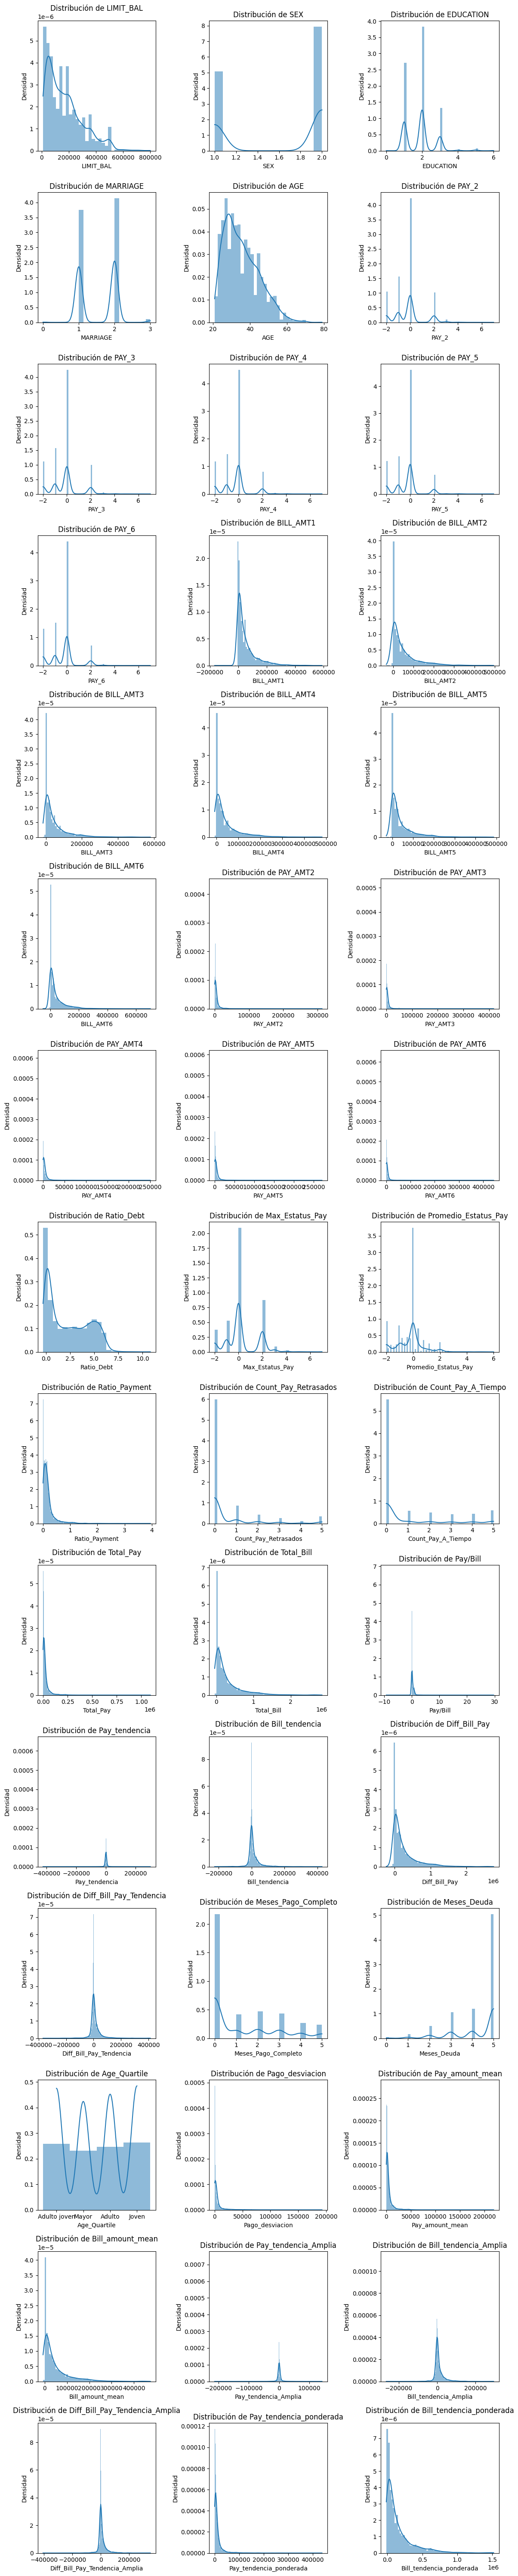

In [189]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

In [190]:
lst_column_log = ['LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT2',
                  'PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','Ratio_Debt','Ratio_Payment','Total_Pay','Total_Bill',
                  'Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Pay_tendencia_ponderada','Bill_tendencia_ponderada','Pago_desviacion']

In [191]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_2', 'PAY_3',
       'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
       'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt', 'Max_Estatus_Pay',
       'Promedio_Estatus_Pay', 'Ratio_Payment', 'Count_Pay_Retrasados',
       'Count_Pay_A_Tiempo', 'Total_Pay', 'Total_Bill', 'Pay/Bill',
       'Pay_tendencia', 'Bill_tendencia', 'Diff_Bill_Pay',
       'Diff_Bill_Pay_Tendencia', 'Meses_Pago_Completo', 'Meses_Deuda',
       'Age_Quartile', 'Pago_desviacion', 'Pay_amount_mean',
       'Bill_amount_mean', 'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada'],
      dtype='object')

In [192]:
lst_column_log

['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Diff_Bill_Pay',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'Pago_desviacion']

In [193]:
for col in lst_column_log:
    offset = abs(df[col].min()) + 1
    df[f'{col}_log'] = np.log1p(np.maximum(df[col] + offset,0))
    X_test[f'{col}_log'] = np.log1p(np.maximum(X_test[col] + offset,0))

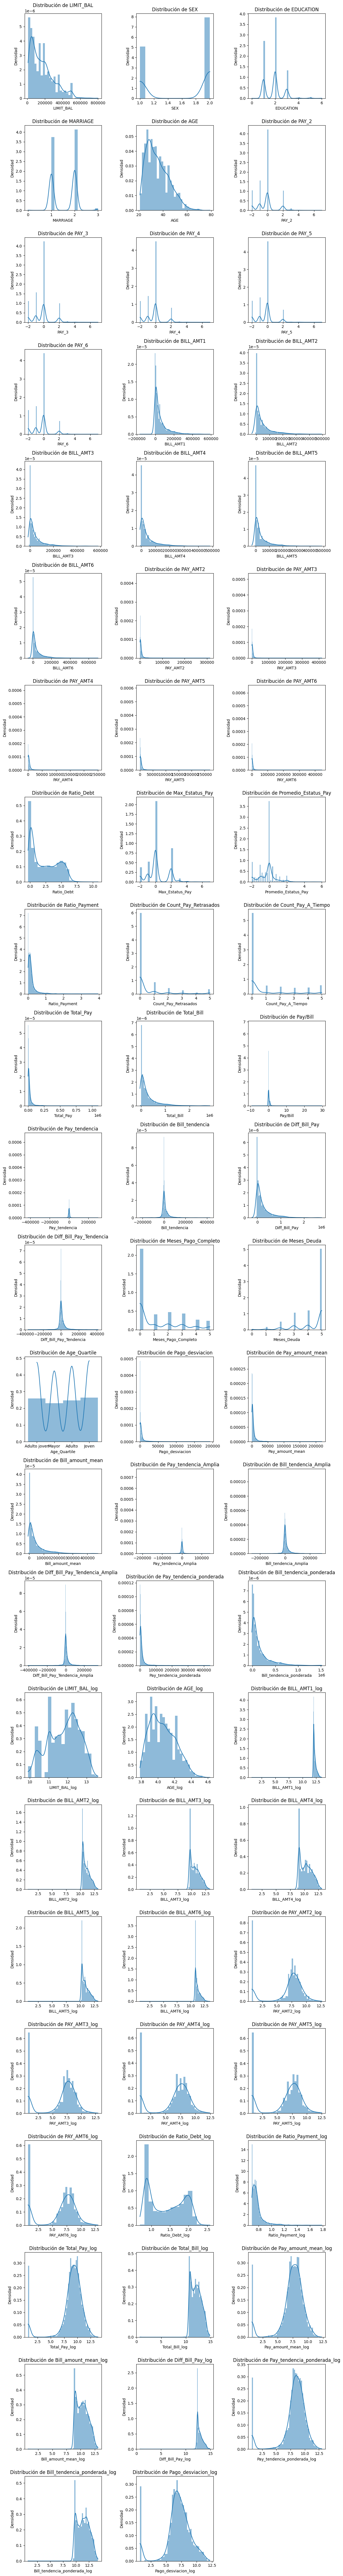

In [194]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

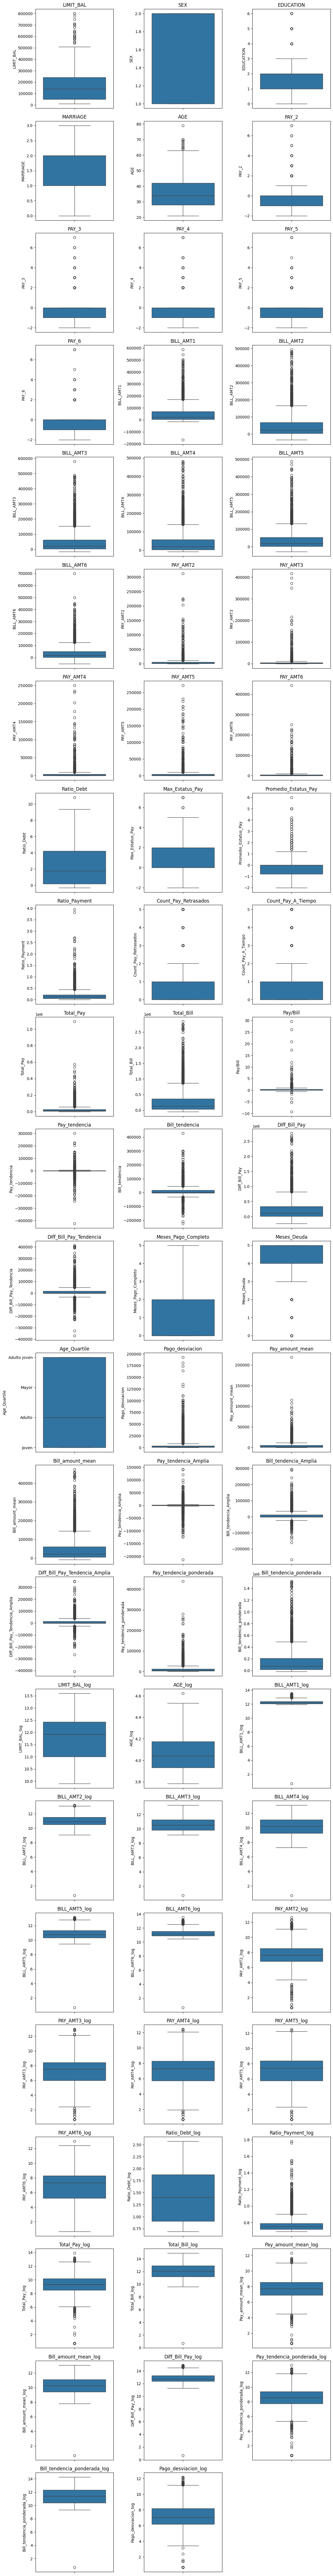

In [195]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i) 
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()


In [196]:
df.isnull().sum().sum()

np.int64(0)

In [197]:
X_test.isnull().sum().sum()

np.int64(0)

In [198]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3.937000e+03,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000
mean,168754.381509,1.609855,1.871476,1.540005,35.581661,-0.135382,-0.177546,-0.235966,-0.273305,-0.305817,52448.366015,50590.969012,48338.869444,44437.905766,41051.000508,39927.318009,5484.474727,5173.183896,4513.285497,4919.008890,5111.174752,2.262755,0.234696,-0.225603,0.183369,0.589281,0.936754,2.520113e+04,2.767944e+05,0.320970,373.299975,10663.651003,2.515933e+05,10290.351029,1.230632,4.286259,5278.951585,5040.225552,46132.404792,41.889552,8653.993396,8612.103844,11490.623736,1.576964e+05,11.790856,4.058479,12.248311,11.094971,10.655077,10.305115,10.901334,11.283634,6.718576,6.411775,6.258207,6.270778,6.128994,1.408143,0.775556,8.913325,12.132800,7.403403,10.341580,12.900023,8.183843,11.411393,6.932809
std,132025.061028,0.487845,0.791688,0.527195,9.269042,1.202432,1.181980,1.133357,1.093208,1.111630,73228.352653,70599.737296,69166.604670,64506.756118,60251.823839,59608.707727,14509.782807,18026.896955,13382.204751,15458.482347,17478.174376,2.099225,1.330263,1.001734,0.255375,1.262022,1.619813,4.624079e+04,3.809835e+05,1.011837,20798.703544,36958.462064,3.673139e+05,44497.363313,1.610164,1.100442,13420.229546,9248.158145,63497.256086,13203.754149,27867.136711,32549.106180,21433.819443,2.160245e+05,0.827892,0.153013,0.325836,0.666656,0.875364,1.056528,0.663728,0.506909,2.999680,3.077895,3.071214,3.132142,3.216988,0.467981,0.097481,2.413842,1.047950,2.087629,1.043295,0.599156,2.252755,1.177764,2.239414
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-33350.000000,-15641.000000,-8318.000000,-28335.000000,-51443.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.293640,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000e+00,-4.426400e+04,-9.222661,-424001.000000,-224013.000000,-2.333200e+05,-367854.000000,0.000000,0.000000,0.000000,0.000000,-7377.333333,-212667.166667,-265620.333333,-407412.833333,0.000000,-1.590550e+04,9.903588,3.784190,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147
1%,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,

### Outiliers

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   SEX                             3937 non-null   int64  
 2   EDUCATION                       3937 non-null   int64  
 3   MARRIAGE                        3937 non-null   int64  
 4   AGE                             3937 non-null   int64  
 5   PAY_2                           3937 non-null   int64  
 6   PAY_3                           3937 non-null   int64  
 7   PAY_4                           3937 non-null   int64  
 8   PAY_5                           3937 non-null   int64  
 9   PAY_6                           3937 non-null   int64  
 10  BILL_AMT1                       3937 non-null   float64
 11  BILL_AMT2                       3937 non-null   float64
 12  BILL_AMT3                       3937

In [200]:
lst_out_upper = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','Pago_desviacion',
           'PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','Promedio_Estatus_Pay','Ratio_Payment','Total_Pay', 'Total_Bill',
                 'Pay/Bill','Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Ratio_Payment_log','Pay_tendencia_ponderada','Bill_tendencia_ponderada']
lst_out_both = ['Pay/Bill','Pay_tendencia','Bill_tendencia','Pay_tendencia_Amplia','Bill_tendencia_Amplia','Diff_Bill_Pay_Tendencia',
                'Diff_Bill_Pay_Tendencia_Amplia','BILL_AMT1_log','BILL_AMT2_log','BILL_AMT3_log','BILL_AMT4_log','BILL_AMT5_log','Pago_desviacion_log',
                'BILL_AMT6_log','PAY_AMT2_log','PAY_AMT3_log','PAY_AMT4_log','PAY_AMT5_log','Total_Pay_log','Diff_Bill_Pay_log','Pay_tendencia_ponderada_log']
lst_out_lower = ['Total_Bill_log','Bill_amount_mean_log','Bill_tendencia_ponderada_log']

In [201]:
for v in lst_out_upper: # Debido a la gran cantidad de outliers vistos en los boxplot, aplicamos winsorize parta no perder tantos datos
    df[v] = winsorize(df[v], limits = [0, 0.1])

for v in lst_out_both:
    df[v] = winsorize(df[v], limits = [0.05, 0.05])

for v in lst_out_lower:
    df[v] = winsorize(df[v], limits = [0.1, 0])


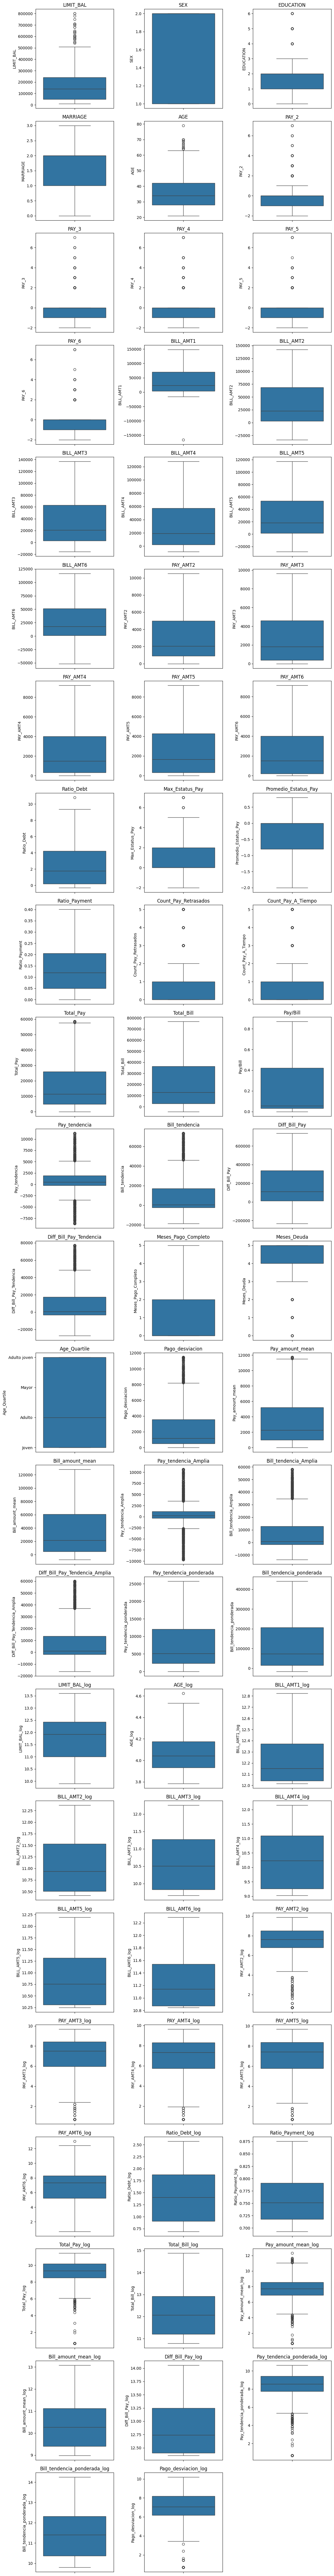

In [202]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()

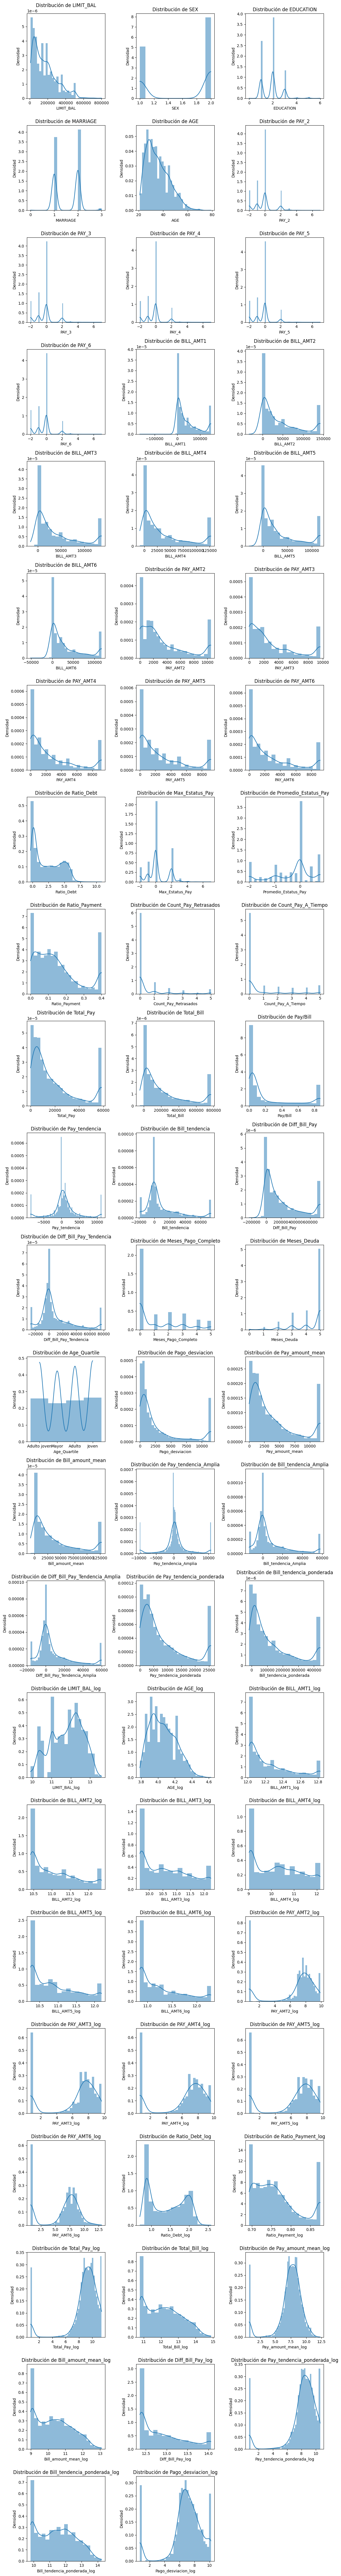

In [203]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

### Codificacion

In [204]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,110000.0,2,2,1,33,2,0,0,0,0,7801.0,5289.0,9893.0,9986.0,9981.0,11714.0,5000.0,500.0,400.0,2000.0,0.0,0.496945,2,0.4,0.071818,1,0,7900.0,54664.0,0.144519,5000.0,-6425.0,46764.0,-11425.0,0,5,Adulto joven,2057.182539,1580.0,9110.666667,966.666667,-2899.333333,-3866.000000,4830.00,26948.65,11.695264,4.025352,12.063258,10.562069,10.147845,9.814984,10.553675,11.053411,8.517593,6.218600,5.996452,7.601902,0.693147,1.026251,0.728427,8.974871,11.502168,7.366445,9.710509,12.542852,8.483016,10.665604,7.630064
1070,60000.0,1,2,1,48,0,0,0,0,-1,60924.0,60089.0,59828.0,58217.0,18527.0,40334.0,2800.0,2000.0,1110.0,9167.0,1800.0,4.965317,0,-0.2,0.400282,0,1,48331.0,297919.0,0.162229,1000.0,19755.0,249588.0,18755.0,1,4,Mayor,11452.770682,9666.2,49653.166667,-9658.000000,21254.333333,40494.833333,16255.80,179693.40,11.156279,4.262680,12.330527,11.445086,11.231504,11.105513,10.755005,11.427139,7.938089,7.601902,7.013915,9.678091,7.496652,1.982236,0.875586,10.785870,12.743107,9.176597,10.951377,13.087586,9.696328,12.183832,9.759429
3385,200000.0,1,2,2,30,-1,-1,-1,-1,-1,15140.0,18028.0,16456.0,15370.0,14966.0,16230.0,10510.0,9631.0,9192.0,9167.0,9133.0,0.480950,-1,-1.0,0.390190,0,5,58532.0,96190.0,0.811290,1514.0,1798.0,18152.0,284.0,1,4,Adulto joven,710.710067,11706.4,16031.666667,12.666667,1019.333333,1006.666667,25702.65,52375.40,12.254872,3.970292,12.104715,10.847004,10.376580,10.072808,10.675977,11.122472,9.709660,9.641733,9.614071,9.678091,9.613269,1.020503,0.871373,11.264977,11.852650,9.655641,10.060961,12.435095,10.475769,11.131415,6.569075
2705,120000.0,2,1,1,51,0,0,0,0,0,117287.0,120290.0,116082.0,118405.0,99081.0,106300.0,6000.0,6000.0,4000.0,9000.0,0.0,5.645375,0,0.0,0.208333,0,0,25000.0,677445.0,0.036903,6000.0,13990.0,652445.0,7990.0,0,5,Mayor,3316.624790,5000.0,112907.500000,833.333333,9957.666667,9124.333333,12600.00,376105.25,11.775305,4.304065,12.552739,11.942380,11.788472,11.749775,11.755228,11.968735,8.699848,8.699848,8.294550,9.105202,0.693147,2.071789,0.792238,10.126711,13.489380,8.517593,11.697634,13.694209,9.441611,12.879050,8.107306
4025,210000.0,2,1,1,40,0,0,0,0,0,148364.0,142398.0,136707.0,127727.0,117100.0,116654.0,5400.0,6000.0,6000.0,6000.0,9133.0,4.788605,0,0.0,0.159048,0,0,33400.0,768437.0,0.033214,-4600.0,61291.0,734849.0,65891.0,0,5,Adulto,1874.033084,6680.0,128072.833333,-2200.000000,42557.000000,44757.000000,13650.00,440500.05,12.301392,4.143135,12.824173,12.365390,12.031767,11.950825,12.069680,12.194127,8.594525,8.699848,8.699848,8.699848,9.210540,1.957591,0.769667,10.416371,13.864180,8.807173,12.072430,14.002429,9.521641,13.307165,7.536915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,20000.0,2,3,2,52,0,0,0,0,2,18603.0,15208.0,16153.0,18175.0,19876.0,19419.0,1500.0,2300.0,2000.0,0.0,1000.0,5.371700,2,0.4,0.340000,1,0,6800.0,107434.0,0.06

In [205]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
3782,100000.0,2,1,2,34,0,0,0,0,2,66193.0,63155.0,50385.0,31371.0,54713.0,28347.0,5010.0,10005.0,30326.0,0.0,20000.0,2.941640,2,0.4,0.653410,1,0,65341.0,294164.0,0.222124,-14990.0,34808.0,228823.0,49798.0,0,5,Adulto joven,12155.010745,13068.2,49027.333333,5113.666667,21767.333333,16653.666667,26407.20,178573.15,11.608254,4.043051,12.353522,11.477371,11.097834,10.588880,11.327198,11.287179,8.519590,9.211040,10.319827,0.693147,9.903588,1.655420,0.975846,11.087406,12.732073,9.478090,10.940343,13.043634,10.181468,12.178088,9.405661
4889,50000.0,2,3,1,48,-1,-1,-1,-1,-1,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,0.0,0.046800,-1,-1.0,0.031200,0,5,1560.0,2340.0,0.666667,390.0,0.0,780.0,-390.0,4,5,Mayor,174.413302,312.0,390.000000,195.000000,0.000000,-195.000000,819.00,1267.50,11.002133,4.262680,12.019574,10.426499,9.682404,9.072227,10.265593,10.855821,5.971262,5.971262,5.971262,5.971262,0.693147,0.850339,0.708627,7.353722,10.749485,5.749393,8.957940,12.363512,6.710523,9.751210,5.172830
1302,50000.0,1,3,2,49,0,0,0,0,0,48245.0,27656.0,23168.0,20245.0,20251.0,19970.0,21578.0,1310.0,706.0,806.0,656.0,3.190700,0,0.0,0.501120,0,0,25056.0,159535.0,0.157056,20922.0,7686.0,134479.0,-13236.0,0,5,Mayor,9264.771514,5011.2,26589.166667,7133.666667,12867.666667,5734.000000,17627.40,101068.85,11.002133,4.276666,12.272923,11.018760,10.566459,10.259937,10.791132,11.176263,9.979522,7.179308,6.562444,6.694562,6.489205,1.701897,0.916739,10.128948,12.224899,8.519830,10.433189,12.815297,9.777323,11.669727,9.134190
313,100000.0,2,1,1,30,-1,-1,-1,-2,-1,0.0,851.0,1585.0,-1.0,-1.0,2994.0,1589.0,0.0,0.0,2995.0,0.0,0.054280,-1,-1.2,0.045840,0,4,4584.0,5428.0,0.844510,1589.0,-2143.0,844.0,-3732.0,3,2,Adulto joven,1350.216168,916.8,904.666667,-967.833333,-185.333333,782.500000,2090.25,2037.60,11.608254,3.970292,12.017222,10.440069,9.754291,9.026297,10.251888,10.904836,7.372118,0.693147,0.693147,8.005367,0.693147,0.853530,0.715808,8.430763,10.813639,6.823068,9.022081,12.363786,7.645995,9.795072,7.209500
5138,90000.0,2,2,2,23,3,3,2,2,2,82623.0,86621.0,84369.0,82117.0,84395.0,85739.0,0.0,0.0,3600.0,2900.0,3500.0,5.620711,3,2.4,0.111111,5,0,10000.0,505864.0,0.019768,-3500.0,882.0,495864.0,4382.0,0,5,Joven,1845.264209,2000.0,84310.666667,-2000.000000,454.000000,2454.000000,3015.00,273342.15,11.512945,3.828641,12.422010,11.695022,11.513045,11.412409,11.632769,11.829078,0.693147,0.693147,8.189245,7.973155,8.161090,2.068678,0.747214,9.210540,13.217910,7.601902,11.426169,13.499684,8.012018,12.575045,7.521461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,180000.0,1,2,2,26,0,0,0,0,0,93169.0,58983.0,60506.0,58458.0,60770.0,61628.0,4000.0,4000.0,4000.0,4000.0,4000.0,2.186189,0,0.0,0.111111,0,0,20000.0,393514.0,0.050824,0.0,-2645.0,373514.0,-2645.0,0,5,Joven,0.000000,4000.0,65585.666667,0.000

In [206]:
df['Age_Quartile'].unique()

array(['Adulto joven', 'Mayor', 'Adulto', 'Joven'], dtype=object)

In [207]:
df = pd.get_dummies(df, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
df = pd.get_dummies(df, columns = ['MARRIAGE'],prefix='MARRIAGE')
df = pd.get_dummies(df, columns = ['SEX'],prefix='SEX')
mapeo_Age = {'Joven':1, 'Adulto joven' :2, 'Adulto':3, 'Mayor':4}
df['Age_Quartile'] = df['Age_Quartile'].map(mapeo_Age)
X_test = pd.get_dummies(X_test, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
X_test = pd.get_dummies(X_test, columns = ['MARRIAGE'],prefix='MARRIAGE')
X_test = pd.get_dummies(X_test, columns = ['SEX'],prefix='SEX')
X_test['Age_Quartile'] = X_test['Age_Quartile'].map(mapeo_Age)

In [208]:
df

,LIMIT_BAL,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,110000.0,33,2,0,0,0,0,7801.0,5289.0,9893.0,9986.0,9981.0,11714.0,5000.0,500.0,400.0,2000.0,0.0,0.496945,2,0.4,0.071818,1,0,7900.0,54664.0,0.144519,5000.0,-6425.0,46764.0,-11425.0,0,5,2,2057.182539,1580.0,9110.666667,966.666667,-2899.333333,-3866.000000,4830.00,26948.65,11.695264,4.025352,12.063258,10.562069,10.147845,9.814984,10.553675,11.053411,8.517593,6.218600,5.996452,7.601902,0.693147,1.026251,0.728427,8.974871,11.502168,7.366445,9.710509,12.542852,8.483016,10.665604,7.630064,False,False,True,False,False,False,False,False,True,False,False,False,True
1070,60000.0,48,0,0,0,0,-1,60924.0,60089.0,59828.0,58217.0,18527.0,40334.0,2800.0,2000.0,1110.0,9167.0,1800.0,4.965317,0,-0.2,0.400282,0,1,48331.0,297919.0,0.162229,1000.0,19755.0,249588.0,18755.0,1,4,4,11452.770682,9666.2,49653.166667,-9658.000000,21254.333333,40494.833333,16255.80,179693.40,11.156279,4.262680,12.330527,11.445086,11.231504,11.105513,10.755005,11.427139,7.938089,7.601902,7.013915,9.678091,7.496652,1.982236,0.875586,10.785870,12.743107,9.176597,10.951377,13.087586,9.696328,12.183832,9.759429,False,False,True,False,False,False,False,False,True,False,False,True,False
3385,200000.0,30,-1,-1,-1,-1,-1,15140.0,18028.0,16456.0,15370.0,14966.0,16230.0,10510.0,9631.0,9192.0,9167.0,9133.0,0.480950,-1,-1.0,0.390190,0,5,58532.0,96190.0,0.811290,1514.0,1798.0,18152.0,284.0,1,4,2,710.710067,11706.4,16031.666667,12.666667,1019.333333,1006.666667,25702.65,52375.40,12.254872,3.970292,12.104715,10.847004,10.376580,10.072808,10.675977,11.122472,9.709660,9.641733,9.614071,9.678091,9.613269,1.020503,0.871373,11.264977,11.852650,9.655641,10.060961,12.435095,10.475769,11.131415,6.569075,False,False,True,False,False,False,False,False,False,True,False,True,False
2705,120000.0,51,0,0,0,0,0,117287.0,120290.0,116082.0,118405.0,99081.0,106300.0,6000.0,6000.0,4000.0,9000.0,0.0,5.645375,0,0.0,0.208333,0,0,25000.0,677445.0,0.036903,6000.0,13990.0,652445.0,7990.0,0,5,4,3316.624790,5000.0,112907.500000,833.333333,9957.666667,9124.333333,12600.00,376105.25,11.775305,4.304065,12.552739,11.942380,11.788472,11.749775,11.755228,11.968735,8.699848,8.699848,8.294550,9.105202,0.693147,2.071789,0.792238,10.126711,13.489380,8.517593,11.697634,13.694209,9.441611,12.879050,8.107306,False,True,False,False,False,False,False,False,True,False,False,False,True
4025,210000.0,40,0,0,0,0,0,148364.0,142398.0,136707.0,127727.0,117100.0,116654.0,5400.0,6000.0,6000.0,6000.0,9133.0,4.788605,0,0.0,0.159048,0,0,33400.0,768437.0,0.033214,-4600.0,61291.0,734849.0,65891.0,0,5,3,1874.033084,6680.0,128072.833333,-2200.000000,42557.000000,44757.000000,13650.00,440500.05,12.301392,4.143135,12.824173,12.365390,12.031767,11.950825,12.069680,12.194127,8.594525,8.699848,8.699848,8.699848,9.210540,1.957591,0.769667,10.416371,13.864180,8.807173,12.072430,14.002429,9.521641,13.307165,7.536915,False,True,False,False,False,False,False,False,True,False,False,False,True
...,...,.

In [209]:
X_test = X_test.reindex(columns=df.columns, fill_value= False)

In [210]:
X_test

,LIMIT_BAL,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
3782,100000.0,34,0,0,0,0,2,66193.0,63155.0,50385.0,31371.0,54713.0,28347.0,5010.0,10005.0,30326.0,0.0,20000.0,2.941640,2,0.4,0.653410,1,0,65341.0,294164.0,0.222124,-14990.0,34808.0,228823.0,49798.0,0,5,2,12155.010745,13068.2,49027.333333,5113.666667,21767.333333,16653.666667,26407.20,178573.15,11.608254,4.043051,12.353522,11.477371,11.097834,10.588880,11.327198,11.287179,8.519590,9.211040,10.319827,0.693147,9.903588,1.655420,0.975846,11.087406,12.732073,9.478090,10.940343,13.043634,10.181468,12.178088,9.405661,False,True,False,False,False,False,False,False,False,True,False,False,True
4889,50000.0,48,-1,-1,-1,-1,-1,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,0.0,0.046800,-1,-1.0,0.031200,0,5,1560.0,2340.0,0.666667,390.0,0.0,780.0,-390.0,4,5,4,174.413302,312.0,390.000000,195.000000,0.000000,-195.000000,819.00,1267.50,11.002133,4.262680,12.019574,10.426499,9.682404,9.072227,10.265593,10.855821,5.971262,5.971262,5.971262,5.971262,0.693147,0.850339,0.708627,7.353722,10.749485,5.749393,8.957940,12.363512,6.710523,9.751210,5.172830,False,False,False,True,False,False,False,False,True,False,False,False,True
1302,50000.0,49,0,0,0,0,0,48245.0,27656.0,23168.0,20245.0,20251.0,19970.0,21578.0,1310.0,706.0,806.0,656.0,3.190700,0,0.0,0.501120,0,0,25056.0,159535.0,0.157056,20922.0,7686.0,134479.0,-13236.0,0,5,4,9264.771514,5011.2,26589.166667,7133.666667,12867.666667,5734.000000,17627.40,101068.85,11.002133,4.276666,12.272923,11.018760,10.566459,10.259937,10.791132,11.176263,9.979522,7.179308,6.562444,6.694562,6.489205,1.701897,0.916739,10.128948,12.224899,8.519830,10.433189,12.815297,9.777323,11.669727,9.134190,False,False,False,True,False,False,False,False,False,True,False,True,False
313,100000.0,30,-1,-1,-1,-2,-1,0.0,851.0,1585.0,-1.0,-1.0,2994.0,1589.0,0.0,0.0,2995.0,0.0,0.054280,-1,-1.2,0.045840,0,4,4584.0,5428.0,0.844510,1589.0,-2143.0,844.0,-3732.0,3,2,2,1350.216168,916.8,904.666667,-967.833333,-185.333333,782.500000,2090.25,2037.60,11.608254,3.970292,12.017222,10.440069,9.754291,9.026297,10.251888,10.904836,7.372118,0.693147,0.693147,8.005367,0.693147,0.853530,0.715808,8.430763,10.813639,6.823068,9.022081,12.363786,7.645995,9.795072,7.209500,False,True,False,False,False,False,False,False,True,False,False,False,True
5138,90000.0,23,3,3,2,2,2,82623.0,86621.0,84369.0,82117.0,84395.0,85739.0,0.0,0.0,3600.0,2900.0,3500.0,5.620711,3,2.4,0.111111,5,0,10000.0,505864.0,0.019768,-3500.0,882.0,495864.0,4382.0,0,5,1,1845.264209,2000.0,84310.666667,-2000.000000,454.000000,2454.000000,3015.00,273342.15,11.512945,3.828641,12.422010,11.695022,11.513045,11.412409,11.632769,11.829078,0.693147,0.693147,8.189245,7.973155,8.161090,2.068678,0.747214,9.210540,13.217910,7.601902,11.426169,13.499684,8.012018,12.575045,7.521461,False,False,True,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

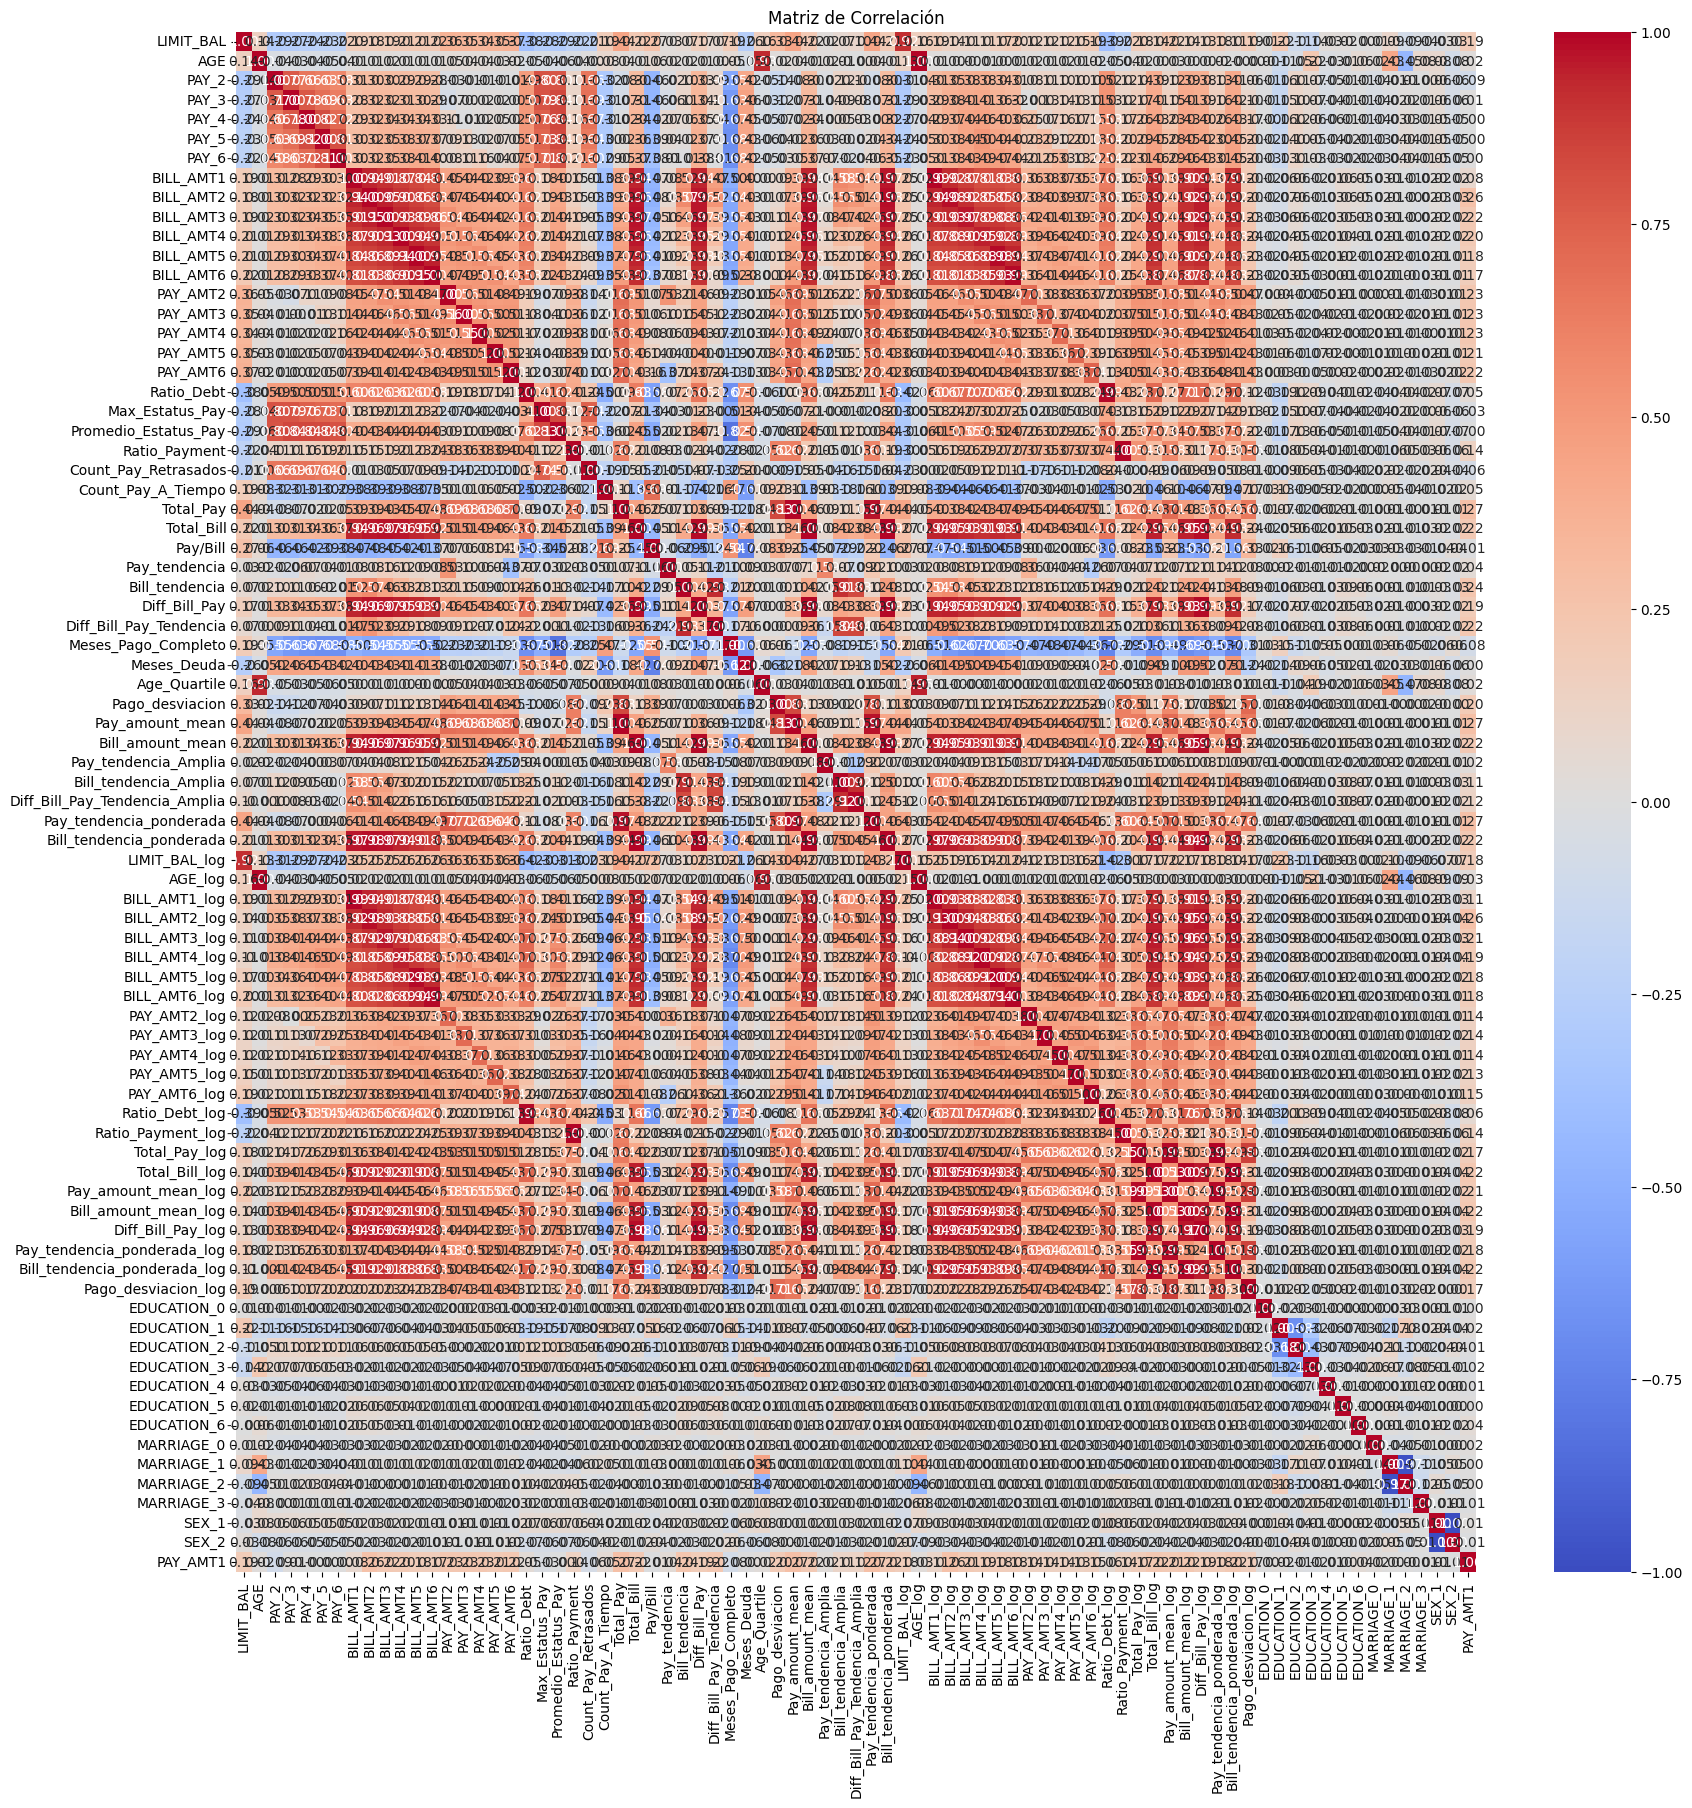

In [211]:
df_corr = df.copy()
df_corr['PAY_AMT1'] = y_train
correlation_matrix = df_corr.corr()
target_correlation = correlation_matrix["PAY_AMT1"].sort_values(ascending=False)
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 78 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   AGE                             3937 non-null   int64  
 2   PAY_2                           3937 non-null   int64  
 3   PAY_3                           3937 non-null   int64  
 4   PAY_4                           3937 non-null   int64  
 5   PAY_5                           3937 non-null   int64  
 6   PAY_6                           3937 non-null   int64  
 7   BILL_AMT1                       3937 non-null   float64
 8   BILL_AMT2                       3937 non-null   float64
 9   BILL_AMT3                       3937 non-null   float64
 10  BILL_AMT4                       3937 non-null   float64
 11  BILL_AMT5                       3937 non-null   float64
 12  BILL_AMT6                       3937

In [213]:
numeric_columns = df.select_dtypes(include = ['float64']).columns

In [214]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt', 'Promedio_Estatus_Pay',
       'Ratio_Payment', 'Total_Pay', 'Total_Bill', 'Pay/Bill', 'Pay_tendencia',
       'Bill_tendencia', 'Diff_Bill_Pay', 'Diff_Bill_Pay_Tendencia',
       'Pago_desviacion', 'Pay_amount_mean', 'Bill_amount_mean',
       'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada', 'LIMIT_BAL_log', 'AGE_log', 'BILL_AMT1_log',
       'BILL_AMT2_log', 'BILL_AMT3_log', 'BILL_AMT4_log', 'BILL_AMT5_log',
       'BILL_AMT6_log', 'PAY_AMT2_log', 'PAY_AMT3_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderad

In [215]:
len(numeric_columns)

53

In [216]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt', 'Promedio_Estatus_Pay',
       'Ratio_Payment', 'Total_Pay', 'Total_Bill', 'Pay/Bill', 'Pay_tendencia',
       'Bill_tendencia', 'Diff_Bill_Pay', 'Diff_Bill_Pay_Tendencia',
       'Pago_desviacion', 'Pay_amount_mean', 'Bill_amount_mean',
       'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada', 'LIMIT_BAL_log', 'AGE_log', 'BILL_AMT1_log',
       'BILL_AMT2_log', 'BILL_AMT3_log', 'BILL_AMT4_log', 'BILL_AMT5_log',
       'BILL_AMT6_log', 'PAY_AMT2_log', 'PAY_AMT3_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderad

In [217]:
categorical_columns = df.select_dtypes(exclude = ['float64']).columns

In [218]:
len(categorical_columns)

25

In [219]:
var_columns = list(categorical_columns) + list(numeric_columns)

In [220]:
var_columns

['AGE',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'Max_Estatus_Pay',
 'Count_Pay_Retrasados',
 'Count_Pay_A_Tiempo',
 'Meses_Pago_Completo',
 'Meses_Deuda',
 'Age_Quartile',
 'EDUCATION_0',
 'EDUCATION_1',
 'EDUCATION_2',
 'EDUCATION_3',
 'EDUCATION_4',
 'EDUCATION_5',
 'EDUCATION_6',
 'MARRIAGE_0',
 'MARRIAGE_1',
 'MARRIAGE_2',
 'MARRIAGE_3',
 'SEX_1',
 'SEX_2',
 'LIMIT_BAL',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Promedio_Estatus_Pay',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay/Bill',
 'Pay_tendencia',
 'Bill_tendencia',
 'Diff_Bill_Pay',
 'Diff_Bill_Pay_Tendencia',
 'Pago_desviacion',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Pay_tendencia_Amplia',
 'Bill_tendencia_Amplia',
 'Diff_Bill_Pay_Tendencia_Amplia',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'LIMIT_BAL_log',
 'AGE_log',
 'BILL_AMT1_log',
 'BILL_AMT2_log',
 'BILL_AM

In [221]:
df[numeric_columns]

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,110000.0,7801.0,5289.0,9893.0,9986.0,9981.0,11714.0,5000.0,500.0,400.0,2000.0,0.0,0.496945,0.4,0.071818,7900.0,54664.0,0.144519,5000.0,-6425.0,46764.0,-11425.0,2057.182539,1580.0,9110.666667,966.666667,-2899.333333,-3866.000000,4830.00,26948.65,11.695264,4.025352,12.063258,10.562069,10.147845,9.814984,10.553675,11.053411,8.517593,6.218600,5.996452,7.601902,0.693147,1.026251,0.728427,8.974871,11.502168,7.366445,9.710509,12.542852,8.483016,10.665604,7.630064
1070,60000.0,60924.0,60089.0,59828.0,58217.0,18527.0,40334.0,2800.0,2000.0,1110.0,9167.0,1800.0,4.965317,-0.2,0.400282,48331.0,297919.0,0.162229,1000.0,19755.0,249588.0,18755.0,11452.770682,9666.2,49653.166667,-9658.000000,21254.333333,40494.833333,16255.80,179693.40,11.156279,4.262680,12.330527,11.445086,11.231504,11.105513,10.755005,11.427139,7.938089,7.601902,7.013915,9.678091,7.496652,1.982236,0.875586,10.785870,12.743107,9.176597,10.951377,13.087586,9.696328,12.183832,9.759429
3385,200000.0,15140.0,18028.0,16456.0,15370.0,14966.0,16230.0,10510.0,9631.0,9192.0,9167.0,9133.0,0.480950,-1.0,0.390190,58532.0,96190.0,0.811290,1514.0,1798.0,18152.0,284.0,710.710067,11706.4,16031.666667,12.666667,1019.333333,1006.666667,25702.65,52375.40,12.254872,3.970292,12.104715,10.847004,10.376580,10.072808,10.675977,11.122472,9.709660,9.641733,9.614071,9.678091,9.613269,1.020503,0.871373,11.264977,11.852650,9.655641,10.060961,12.435095,10.475769,11.131415,6.569075
2705,120000.0,117287.0,120290.0,116082.0,118405.0,99081.0,106300.0,6000.0,6000.0,4000.0,9000.0,0.0,5.645375,0.0,0.208333,25000.0,677445.0,0.036903,6000.0,13990.0,652445.0,7990.0,3316.624790,5000.0,112907.500000,833.333333,9957.666667,9124.333333,12600.00,376105.25,11.775305,4.304065,12.552739,11.942380,11.788472,11.749775,11.755228,11.968735,8.699848,8.699848,8.294550,9.105202,0.693147,2.071789,0.792238,10.126711,13.489380,8.517593,11.697634,13.694209,9.441611,12.879050,8.107306
4025,210000.0,148364.0,142398.0,136707.0,127727.0,117100.0,116654.0,5400.0,6000.0,6000.0,6000.0,9133.0,4.788605,0.0,0.159048,33400.0,768437.0,0.033214,-4600.0,61291.0,734849.0,65891.0,1874.033084,6680.0,128072.833333,-2200.000000,42557.000000,44757.000000,13650.00,440500.05,12.301392,4.143135,12.824173,12.365390,12.031767,11.950825,12.069680,12.194127,8.594525,8.699848,8.699848,8.699848,9.210540,1.957591,0.769667,10.416371,13.864180,8.807173,12.072430,14.002429,9.521641,13.307165,7.536915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,20000.0,18603.0,15208.0,16153.0,18175.0,19876.0,19419.0,1500.0,2300.0,2000.0,0.0,1000.0,5.371700,0.4,0.340000,6800.0,107434.0,0.063295,500.0,-4211.0,100634.0,-4711.0,907.193474,1360.0,17905.666667,1433.333333,-2502.000000,-3935.333333,3555.00,56755.20,10.309019,4.317488,12.123696,10.790555,10.367096,10.184711,10.783384,11.168518,7.314553,7.741534,7.601902,0.693147,6.909753,2.036709,0.850151,8.824972,11.929660,7.216709,10.137967,12.718765,8.176673,11.193583,6.812558
70,20000.0,15397.0,10403.0,7207.0,7351.0,7512.0,8380.0,1500.0,264.0,280.0,1000.0,813.0,2.812500,0.4,

In [222]:
sc = StandardScaler()
df[numeric_columns] = sc.fit_transform(df[numeric_columns])

In [223]:
df[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03
mean,8.798313e-17,-1.353587e-17,9.836063e-17,6.948411e-17,1.759663e-17,-8.572715e-18,2.301097e-17,1.263348e-17,3.474206e-17,2.436456e-17,3.429086e-17,6.136259e-17,-1.060310e-16,-3.970521e-17,8.482476e-17,-1.263348e-17,2.932771e-17,4.241238e-17,-1.985260e-17,-1.443826e-17,-3.474206e-17,2.977891e-17,1.010678e-16,-7.399607e-17,1.669423e-17,1.353587e-17,-2.075499e-17,-4.511955e-17,1.967213e-16,1.335539e-16,-1.082418e-15,-3.195367e-15,-4.104075e-15,-9.050983e-16,-3.293727e-16,-1.383366e-15,-1.754248e-15,-4.356293e-16,-1.552113e-16,8.888552e-17,2.237930e-16,-4.123927e-16,8.301998e-17,-3.984057e-16,8.329070e-16,-1.782222e-17,-1.924349e-15,-1.046774e-16,5.355691e-16,1.086930e-15,-2.377800e-16,-1.011129e-15,-4.096855e-16
std,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00
min,-1.202609e+00,-4.252328e+00,-1.598231e+00,-1.234959e+00,-1.070155e+00,-1.593174e+00,-2.173016e+00,-1.000883e+00,-9.382808e-01,-8.968630e-01,-9.217367e-01,-8.929979e-01,-1.217935e+00,-2.070575e+00,-1.206311e+00,-1.014640e+00,-1.099728e+00,-7.956281e-01,-2.339347e+00,-1.271678e+00,-1.809401e+00,-1.493294e+00,-7.947182e-01,-1.014640e+00,-1.099728e+00,-2.520092e+00,-1.228088e+00,-1.320559e+00,-1.039415e+00,-1.032130e+00,-2.279896e+00,-1.792819e+00,-9.276994e-01,-1.090168e+00,-1.189884e+00,-1.252627e+00,-1.047649e+00,-9.566296e-01,-2.027252e+00,-1.878661e+00,-1.831317e+00,-1.799831e+00,-1.689946e+00,-1.528027e+00,-1.247939e+00,-3.444194e+00,-1.329876e+00,-3.214703e+00,-1.329835e+00,-1.010676e+00,-3.368742e+00,-1.407920e+00,-2.837040e+00
25%,-8.995979e-01,-8.165500e-01,-8.293412e-01,-8.260623e-01,-8.230874e-01,-8.272725e-01,-8.173757e-01,-7.325535e-01,-8.120228e-01,-7.917538e-01,-8.147741e-01,-8.293040e-01,-9.929274e-01,-5.924063e-01,-7.962552e-01,-7.436785e-01,-8.098043e-01,-6.920329e-01,-2.532607e-01,-5.386869e-01,-8.186983e-01,-5.226960e-01,-6.589608e-01,-7.436785e-01,-8.0

In [224]:
X_test[numeric_columns] = sc.transform(X_test[numeric_columns])

In [225]:
X_test[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,0.038606,0.100308,0.112509,0.116596,0.129942,0.162486,0.139503,0.588267,0.754006,1.001701,0.577709,0.791741,-0.036952,0.089612,0.297873,0.390637,0.122931,0.301084,-0.097891,-0.021777,0.115223,-0.017132,0.645604,0.390637,0.122931,0.066410,-0.047107,-0.096035,0.424360,0.111732,0.047730,-0.035020,-0.016993,-0.026917,-0.028588,-0.023118,-0.009830,-0.005747,-0.009597,0.033944,0.013261,-0.019350,0.001836,-0.041998,0.240641,0.016413,-0.044320,0.005914,-0.043281,-0.029225,0.020291,-0.049973,0.017125
std,0.986920,1.440240,1.464612,1.461557,1.491746,1.570961,1.528216,4.777094,4.370335,6.510388,4.316809,4.905063,1.002698,1.267073,1.955190,2.472102,1.472902,2.506519,5.003421,1.794174,1.470233,1.974113,3.591602,2.472102,1.472902,3.140558,1.689955,1.908336,2.696235,1.448547,0.990877,0.981987,1.077831,1.030299,1.026594,1.050755,1.137050,1.057589,1.030207,1.030802,1.040804,1.035249,1.001572,1.007168,1.719813,1.021794,1.036861,1.006128,1.025840,1.049222,1.023972,1.030482,1.041389
min,-1.202609,-1.047609,-1.103653,-1.133424,-1.241498,-2.947415,-1.491947,-1.000883,-0.938281,-0.896863,-0.921737,-0.892998,-1.551665,-2.070575,-1.206311,-1.014640,-1.239419,-11.081407,-46.110199,-18.251076,-1.459052,-33.175686,-0.794718,-1.014640,-1.239419,-35.147123,-15.489125,-21.857197,-1.039415,-1.127198,-2.279896,-1.792819,-1.117310,-1.659004,-2.663872,-10.164157,-17.837721,-2.440894,-2.027252,-1.878661,-1.831317,-1.799831,-1.689946,-2.449456,-1.247939,-3.444194,-11.867500,-3.214703,-10.116914,-2.882571,-3.368742,-9.915134,-2.837040
25%,-0.823845,-0.827903,-0.840685,-0.833519,-0.824731,-0.827324,-0.818223,-0.771685,-0.796726,-0.789889,-0.854252,-0.828457,-0.995867,-0.838768,-0.834055,-0.739887,-0.805469,-0.690688,-0.285751,-0.561881,-0.828528,-0.532247,-0.660039,-0.739887,-0.805469,-0.166642,-0.572047,-0.569261,-0.740181,-0.811919,-0.766594,-0.827837,-0.843754,-0.966144,-1.006456,-1.030877,-0.955670,-0.899991,-0.012477,-0.094173,-0.151623,-0.299389,-0.270134,-1.080312,-0.844457,-0.154461,-0.905114,-0.236494,-0.905118,-0.947249,-0.167893,-0.914397,-0.326466
50%,-0.142070,-0.470792,-0.473592,-0.452689,-0.436070,-0.411730,-0.425934,-0.375825,-0.292261,-0.388270,-0.398564,-0.384802,-0.338166,0.393039,-0.238016,-0.393726,-0.431198,-0.590293,-0.095645,-0.419605,-0.448738,-0.371738,-0.444793,-0.393726,-0.431198,-0.033265,-0.425589,-0.404631,-0.365932,-0.447049,0.232048,-0.100841,-0.434520,-0.324045,-0.201961,-0.093878,-0.245735,-0.330216,0.326452,0.407096,0.363516,0.363625,0.368577,-0.130267,-0.216638,0.188240,-0.103039,0.153570,-0.103068,-0.332000,0

In [226]:

X_test.isnull().sum().sum()

np.int64(0)

In [227]:
X_test.isnull().sum().sum()

np.int64(0)

In [228]:
df[categorical_columns]

,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,33,2,0,0,0,0,2,1,0,0,5,2,False,False,True,False,False,False,False,False,True,False,False,False,True
1070,48,0,0,0,0,-1,0,0,1,1,4,4,False,False,True,False,False,False,False,False,True,False,False,True,False
3385,30,-1,-1,-1,-1,-1,-1,0,5,1,4,2,False,False,True,False,False,False,False,False,False,True,False,True,False
2705,51,0,0,0,0,0,0,0,0,0,5,4,False,True,False,False,False,False,False,False,True,False,False,False,True
4025,40,0,0,0,0,0,0,0,0,0,5,3,False,True,False,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,52,0,0,0,0,2,2,1,0,0,5,4,False,False,False,True,False,False,False,False,False,True,False,False,True
70,26,2,0,0,0,0,2,1,0,0,5,1,False,True,False,False,False,False,False,False,False,True,False,True,False
2878,53,2,2,2,2,2,2,5,0,0,5,4,False,False,True,False,False,False,False,False,True,False,False,False,True
1950,26,2,2,2,2,2,2,5,0,0,5,1,False,False,True,False,False,False,False,False,False,True,False,False,True


In [229]:
df[var_columns]

,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT1_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT2_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,33,2,0,0,0,0,2,1,0,0,5,2,False,False,True,False,False,False,False,False,True,False,False,False,True,-0.445081,-0.738794,-0.785040,-0.672084,-0.638759,-0.614116,-0.551245,0.489835,-0.776412,-0.761238,-0.246893,-0.892998,-0.841279,0.885762,-0.615075,-0.580530,-0.707866,-0.322684,1.053550,-0.723841,-0.667696,-0.852979,-0.223499,-0.580530,-0.707866,0.138808,-0.617092,-0.650525,-0.436829,-0.736017,-0.115479,-0.216529,-0.737775,-0.850960,-0.598873,-0.474097,-0.553456,-0.496978,0.620373,-0.049972,-0.073402,0.446305,-1.689946,-0.816146,-0.611255,0.037798,-0.625136,-0.017705,-0.625156,-0.661820,0.147928,-0.657349,0.332218
1070,48,0,0,0,0,-1,0,0,1,1,4,4,False,False,True,False,False,False,False,False,True,False,False,True,False,-0.823845,0.337734,0.368274,0.428691,0.497971,-0.395747,0.183671,-0.166081,-0.290804,-0.520504,2.171408,-0.283163,1.287573,0.146678,2.088970,1.641176,0.255688,-0.264730,0.061475,0.443346,0.159074,0.384198,2.385380,1.641176,0.255688,-2.520092,0.763174,1.746061,0.988643,0.319413,-0.766594,1.334701,0.364846,0.584026,0.708002,0.800007,-0.223728,0.340417,0.424281,0.407842,0.263862,1.121304,0.425190,1.226901,2.044520,0.799220,0.587774,0.849490,0.587758,0.362210,0.695667,0.660478,1.305058
3385,30,-1,-1,-1,-1,-1,-1,0,5,1,4,2,False,False,True,False,False,False,False,False,False,True,False,True,False,0.236694,-0.590070,-0.516936,-0.527408,-0.511866,-0.486738,-0.435281,2.132606,2.179644,2.219796,2.171408,2.201237,-0.848900,-0.838768,2.005889,2.201726,-0.543378,1.859344,0.188957,-0.357234,-0.784327,-0.372989,-0.597375,2.201726,-0.543378,-0.099938,-0.393159,-0.387280,2.167224,-0.560325,0.560551,-0.576412,-0.566744,-0.387913,-0.323022,-0.219554,-0.353156,-0.342235,1.023743,1.082938,1.125750,1.121304,1.083223,-0.828431,1.968482,1.000657,-0.282571,1.078987,-0.282599,-0.864389,1.047539,-0.253024,-0.152514
2705,51,0,0,0,0,0,0,0,0,0,5,4,False,True,False,False,False,False,False,False,True,False,False,False,True,-0.369328,1.479920,1.635257,1.668763,1.916509,1.662585,1.877573,0.787979,1.004150,0.459386,2.115058,-0.892998,1.611571,0.393039,0.508772,0.359124,1.759022,-0.674861,1.301569,0.186324,1.801238,-0.057094,0.126211,0.359124,1.759022,0.105440,0.117624,0.051275,0.532549,1.676574,-0.018786,1.605204,1.281588,1.392178,1.379695,1.436068,1.414386,1.553945,0.682044,0.771215,0.688361,0.935049,-1.689946,1.418286,0.540344,0.522081,1.317191,0.533779,1.317204,1.502585,0.580677,1.263930,0.550255
4025,40,0,0,0,0,0,0,0,0,0,5,3,False,True,False,False,False,False,False,False,True,False,False,False,True,0.312447,2.109689,2.100539,2.123424,2.136214,2.123010,2.143447,0.609092,1.004150,1.137510,1.102793,2.201237,1.203383,0.393039,0.103032,0.820709,2.119449,-0.686935,-1.327430,2.295151,2.137141,2.316457,-0.274354,0.820709,2.119449,-0.653673,1.980519,1.976324,0.663546,2.121527,0.616748,0.553327,2.401393,2.079609,1.673105,1.634560,1.929379,2.058969,0.646405,0.771215,0.822708,0.803263,0.958020,1.1

## Entrenamiento

In [230]:
model_Regression = LinearRegression() 

In [231]:
y_train

1779        0.0
1070     2400.0
3385    18044.0
2705     6500.0
4025     7876.0
         ...   
1993     1555.0
70          0.0
2878     3656.0
1950     6000.0
1922     2574.0
Name: PAY_AMT1, Length: 3937, dtype: float64

In [232]:
model_Regression.fit(df[var_columns],y_train)

LinearRegression()

In [233]:
model_RandFor = RandomForestRegressor()

In [234]:
model_RandFor.fit(df[var_columns],y_train)

RandomForestRegressor()

In [235]:
cv_scores = cross_val_score(model_Regression,df[var_columns],y_train, cv=5, scoring='r2')

In [236]:
print(cv_scores)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

[0.53048656 0.39921492 0.52407672 0.49075786 0.46036832]
r2: 0.48 (+/- 0.10)


In [237]:
y_pred = model_Regression.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: -195637.37622194766


In [238]:
cv_scores_RandFor = cross_val_score(model_RandFor, df[var_columns],y_train, cv=5, scoring='r2')

In [239]:
print(cv_scores_RandFor)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RandFor.mean(), cv_scores_RandFor.std() * 2))

[0.5665509  0.40857856 0.43300211 0.53521927 0.58090554]
r2: 0.50 (+/- 0.14)


In [241]:
y_pred = model_RandFor.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: 0.5506375268977376


In [253]:
xgb_r = XGBRegressor(enable_categorical=True, tree_method='hist')

In [254]:
xgb_r.fit(df[var_columns],y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [255]:
cv_scores_xgb_r = cross_val_score(xgb_r,df[var_columns],y_train, cv=5, scoring = 'r2')

In [256]:
print(cv_scores_xgb_r)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_xgb_r.mean(), cv_scores_xgb_r.std() * 2))

[0.60047945 0.61100938 0.41511211 0.69577392 0.36588619]
r2: 0.54 (+/- 0.25)


In [257]:
y_pred = xgb_r.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"R2 XGB: {r2}")

R2 XGB: 0.5311005401522809


### Modelo con SelectKbest

In [391]:
selector = SelectKBest(score_func = f_regression, k = 47)

X_train_selected = selector.fit_transform(df[var_columns],y_train)
X_test_selected = selector.transform(X_test[var_columns])

In [392]:
model_k_best = LinearRegression()# Marcaba error de que el modelo no convergia 

In [393]:
model_k_best.fit(X_train_selected, y_train)

LinearRegression()

In [394]:
cv_scores_kbest = cross_val_score(model_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [395]:
print(cv_scores_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_kbest.mean(), cv_scores_kbest.std() * 2))

[0.55894738 0.41712621 0.51462119 0.48023507 0.45037117]
r2: 0.48 (+/- 0.10)


In [396]:
y_pred = model_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: -204888.2420688897


In [397]:
model_RF_k_best = RandomForestRegressor()

In [398]:
model_RF_k_best.fit(X_train_selected,y_train)

RandomForestRegressor()

In [399]:
cv_scores_RF_k_best = cross_val_score(model_RF_k_best, X_train_selected, y_train, cv=5, scoring = 'r2')

In [400]:
print(cv_scores_RF_k_best)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RF_k_best.mean(), cv_scores_RF_k_best.std() * 2))

[0.62743074 0.45852561 0.42366364 0.5465242  0.60893942]
r2: 0.53 (+/- 0.16)


In [401]:
y_pred = model_RF_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 LDA SelectKbeast con conjunto de prueba: {r2}")

R2 LDA SelectKbeast con conjunto de prueba: 0.58600065683434


In [402]:
model_XGBr_k_best = XGBRegressor()

In [403]:
model_XGBr_k_best.fit(X_train_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [404]:
cv_scores_XGBr_kbest = cross_val_score(model_XGBr_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [405]:
print(cv_scores_XGBr_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_XGBr_kbest.mean(), cv_scores_XGBr_kbest.std() * 2))

[0.67531456 0.60367598 0.355964   0.55616161 0.20643379]
r2: 0.48 (+/- 0.35)


In [406]:
y_pred = model_XGBr_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: 0.5329242152008069
